Urban Threads E-Commerce Analysis (Audit)

Objective: Cleaned transaction data to calculate true Net Revenue and identify top-performing product categories.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('urban_threads_sales.csv')

In [3]:
df

,Order_ID,Order_Date,Category,Customer_Age,Price,Quantity,Discount_Applied
0,1001,2026-03-01,Joggers,19,45.0,2,5.0
1,1002,2026-03-01,T-Shirt,24,20.0,3,NaN
2,1003,2026-03-02,Sunglasses,22,35.0,1,0.0
3,1004,2026-03-02,Joggers,31,45.0,1,10.0
4,1005,2026-03-03,Hoodie,19,60.0,2,15.0
5,1006,2026-03-04,T-Shirt,28,20.0,4,NaN
6,1007,2026-03-04,Sunglasses,25,35.0,2,5.0
7,1008,2026-03-05,Joggers,19,45.0,3,10.0
8,1009,2026-03-06,Hoodie,34,60.0,1,0.0
9,1010,2026-03-07,Sunglasses,21,35.0,3,15.0


In [12]:
df['Discount_Applied']=df['Discount_Applied'].fillna(0)

In [13]:
df.dtypes

Order_ID                     int64
Order_Date          datetime64[ns]
Category                    object
Customer_Age                 int64
Price                      float64
Quantity                     int64
Discount_Applied           float64
dtype: object

In [14]:
df['Order_Date']=pd.to_datetime(df['Order_Date'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          12 non-null     int64         
 1   Order_Date        12 non-null     datetime64[ns]
 2   Category          12 non-null     object        
 3   Customer_Age      12 non-null     int64         
 4   Price             12 non-null     float64       
 5   Quantity          12 non-null     int64         
 6   Discount_Applied  12 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 804.0+ bytes


In [16]:
df

,Order_ID,Order_Date,Category,Customer_Age,Price,Quantity,Discount_Applied
0,1001,2026-03-01,Joggers,19,45.0,2,5.0
1,1002,2026-03-01,T-Shirt,24,20.0,3,0.0
2,1003,2026-03-02,Sunglasses,22,35.0,1,0.0
3,1004,2026-03-02,Joggers,31,45.0,1,10.0
4,1005,2026-03-03,Hoodie,19,60.0,2,15.0
5,1006,2026-03-04,T-Shirt,28,20.0,4,0.0
6,1007,2026-03-04,Sunglasses,25,35.0,2,5.0
7,1008,2026-03-05,Joggers,19,45.0,3,10.0
8,1009,2026-03-06,Hoodie,34,60.0,1,0.0
9,1010,2026-03-07,Sunglasses,21,35.0,3,15.0


In [17]:
df['Net_Revenue']=(df['Price']*df['Quantity'])-df['Discount_Applied']

In [18]:
df

,Order_ID,Order_Date,Category,Customer_Age,Price,Quantity,Discount_Applied,Net_Revenue
0,1001,2026-03-01,Joggers,19,45.0,2,5.0,85.0
1,1002,2026-03-01,T-Shirt,24,20.0,3,0.0,60.0
2,1003,2026-03-02,Sunglasses,22,35.0,1,0.0,35.0
3,1004,2026-03-02,Joggers,31,45.0,1,10.0,35.0
4,1005,2026-03-03,Hoodie,19,60.0,2,15.0,105.0
5,1006,2026-03-04,T-Shirt,28,20.0,4,0.0,80.0
6,1007,2026-03-04,Sunglasses,25,35.0,2,5.0,65.0
7,1008,2026-03-05,Joggers,19,45.0,3,10.0,125.0
8,1009,2026-03-06,Hoodie,34,60.0,1,0.0,60.0
9,1010,2026-03-07,Sunglasses,21,35.0,3,15.0,90.0


In [20]:
df.groupby('Category')['Net_Revenue'].sum()

Category
Hoodie        165.0
Joggers       335.0
Sunglasses    190.0
T-Shirt       230.0
Name: Net_Revenue, dtype: float64

In [21]:
df.groupby('Category')['Quantity'].sum()

Category
Hoodie         3
Joggers        8
Sunglasses     6
T-Shirt       12
Name: Quantity, dtype: int64

Key Finding 1: While T-Shirts drive the highest sales volume, Joggers generate the most actual profit ($335 Net Revenue).

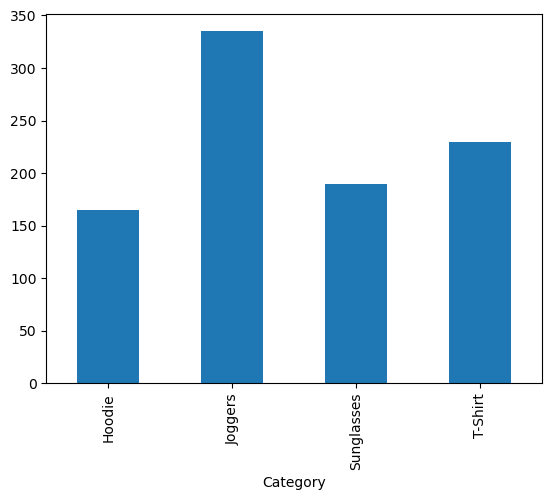

In [23]:
df.groupby('Category')['Net_Revenue'].sum().plot(kind='bar')
plt.show()

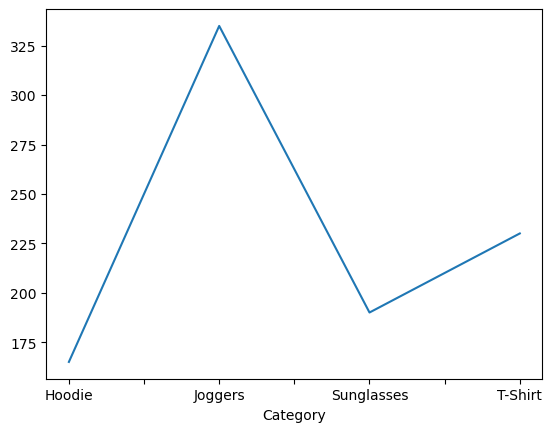

In [28]:
df.groupby('Category')['Net_Revenue'].sum().plot(kind='line')
plt.show()